# RNN

In [1]:
# RNN >> is neural network which is designed for sequential data
# sequential data >> text data ,audio,time series, #DNA sequence
# RNN neural network with memeory

In [2]:
# ANN >> structured(tabular)/images
# CNN >> images,video
# RNN >> sequential data(text,audio,time series)

## applications

In [3]:

# 1) sentiment analysis
# 2) chatbot
# 3) langauge translataion
# 4) word prediction
# 5) stock market prediction
# 6) weather forcasting
# 7) alexa /siri  Speech recognition
# 8) Text generation


## types of architectures of RNN

In [4]:
# one to one >> image classification >> image >> Label
# one to many >> image >> caption
# many to one >> sentiment analysis >> review >> good
# many to many >> Lang translation

## types of RNN

In [5]:
# simple RNN  >> vanishing gradient,can not Handles Long dependencies
# LSTM(Long short term memory)   >> uses memory  >> Handles Long Dependencies
# GRU(Gated recurrent unit)

In [6]:
# memory

In [7]:
# RNN remember past input
#ex-- for example we write email..then automatically next word visible  
# RNN >> i m going to ___


## 1) simple RNN

In [8]:
# input >> 1 2 3 4
# output >> 5  # lern past pattern and then give output   >> many to one

In [9]:
import numpy as np
import pandas as pd
from tensorflow.keras.layers import Dense,SimpleRNN
from tensorflow.keras.models import Sequential

C:\Users\BusinessComputers.in\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [10]:
# data

In [11]:
X=np.array([[1,2,3,4]])
y=np.array([5])

In [12]:
X.shape

(1, 4)

In [13]:
# input >> reshape

In [14]:
# cnn  >> 1, 256,256,3    >> 1 image    256,256,3  >> shape of  3d or colur iamge ..cooman
# RNN  >> 1,4,1 >> 1,4,1    >> 1 aaray 4 column and 1 row

In [15]:
X_new=X.reshape((1,4,1))    # we have to reshape X bcz we want each column seprate

In [16]:
X_new

array([[[1],
        [2],
        [3],
        [4]]])

In [17]:
y

array([5])

In [18]:
model=Sequential([
    SimpleRNN(10,activation='relu',input_shape=(4,1)), #10 is a number of unit   >> 4 row 1 column
    Dense(1)

]
)   

C:\Users\BusinessComputers.in\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model.compile(optimizer='adam',loss='mse')

In [20]:
model.fit(X_new,y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 14.5128
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 14.3066
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 14.1016
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 13.8977
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 13.6951
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 13.4917
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 13.2896
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 13.0888
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 12.8894
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 12.6914
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 12.4949
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 12.2998
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 12.1062
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 11.9142
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 11.

In [21]:
model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step


array([[3.9319685]], dtype=float32)

In [22]:
a=np.array([[6,7,8,9]])       # many to one ka example

In [23]:
a_new=a.reshape((1,4,1))

In [24]:
a_new

array([[[6],
        [7],
        [8],
        [9]]])

In [25]:
model.predict(a_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


array([[7.339924]], dtype=float32)

# LSTM section 1

# Case study -1 Restaurant reviews predictions

In [26]:
# many to one

## LSTM /GRU algorithm use

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,LSTM,GRU,Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pandas as pd

In [28]:
df=pd.read_csv('r_data.tsv',delimiter='\t')

In [29]:
df

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
...,...,...
1381,clean,1
1382,less,0
1383,clean,1
1384,less,0


In [30]:
df.shape

(1386, 2)

In [31]:
# Data Cleaning


In [32]:
df.isnull().sum()

Review    0
Liked     0
dtype: int64

In [33]:
df.dtypes

Review    object
Liked      int64
dtype: object

In [34]:
# ann ,cnn  >> == input data >> image
# text data === input data >> unstructure data

In [35]:
df['Review']

0                                Wow... Loved this place.
1                                      Crust is not good.
2               Not tasty and the texture was just nasty.
3       Stopped by during the late May bank holiday of...
4       The selection on the menu was great and so wer...
                              ...                        
1381                                                clean
1382                                                 less
1383                                                clean
1384                                                 less
1385                                                clean
Name: Review, Length: 1386, dtype: object

# text preprocessing


In [36]:
# Lowercase,special characters dighit  remove stopwords steming

In [37]:
# NLP use

In [38]:
# nltk

In [39]:
X=df[['Review']]  # X is always 2d
y=df['Liked']

In [40]:
X

,Review
0,Wow... Loved this place.
1,Crust is not good.
2,Not tasty and the texture was just nasty.
3,Stopped by during the late May bank holiday of...
4,The selection on the menu was great and so wer...
...,...
1381,clean
1382,less
1383,clean
1384,less


In [41]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import re

In [42]:
s_list=stopwords.words('english')

In [43]:
s_list.remove('not')

In [44]:
len(s_list)

197

In [45]:
df['Review']

0                                Wow... Loved this place.
1                                      Crust is not good.
2               Not tasty and the texture was just nasty.
3       Stopped by during the late May bank holiday of...
4       The selection on the menu was great and so wer...
                              ...                        
1381                                                clean
1382                                                 less
1383                                                clean
1384                                                 less
1385                                                clean
Name: Review, Length: 1386, dtype: object

In [46]:
for i in df['Review']:
    print(i)

Wow... Loved this place.
Crust is not good.
Not tasty and the texture was just nasty.
Stopped by during the late May bank holiday off Rick Steve recommendation and loved it.
The selection on the menu was great and so were the prices.
Now I am getting angry and I want my damn pho.
Honeslty it didn't taste THAT fresh.)
The potatoes were like rubber and you could tell they had been made up ahead of time being kept under a warmer.
The fries were great too.
A great touch.
Service was very prompt.
Would not go back.
The cashier had no care what so ever on what I had to say it still ended up being wayyy overpriced.
I tried the Cape Cod ravoli, chicken, with cranberry...mmmm!
I was disgusted because I was pretty sure that was human hair.
I was shocked because no signs indicate cash only.
Highly recommended.
Waitress was a little slow in service.
This place is not worth your time, let alone Vegas.
did not like at all.
The Burrittos Blah!
The food, amazing.
Service is also cute.
I could care les

In [47]:
corpus=[]
for i in df['Review']:
    mystr=i.lower()     # lowercase
    #print(mystr)
    newstr=re.sub(r'[^A-Za-z/s]',' ',mystr)  # remove special characters & digit
    #print(newstr)
    list1=word_tokenize(newstr)  # breakdown sentence into word
    #print(list1)
    list2=[ i for i in list1 if i not in s_list]  # stopwords removal
    #print(list2)
    ps=PorterStemmer()
    list3=[ ps.stem(i) for i in list2]  # stemming >>  remove suffix
    #print(list3)
    final=' '.join(list3)
    corpus.append(final)
    

    

In [48]:
corpus

['wow love place',
 'crust not good',
 'not tasti textur nasti',
 'stop late may bank holiday rick steve recommend love',
 'select menu great price',
 'get angri want damn pho',
 'honeslti tast fresh',
 'potato like rubber could tell made ahead time kept warmer',
 'fri great',
 'great touch',
 'servic prompt',
 'would not go back',
 'cashier care ever say still end wayyy overpr',
 'tri cape cod ravoli chicken cranberri mmmm',
 'disgust pretti sure human hair',
 'shock sign indic cash',
 'highli recommend',
 'waitress littl slow servic',
 'place not worth time let alon vega',
 'not like',
 'burritto blah',
 'food amaz',
 'servic also cute',
 'could care less interior beauti',
 'perform',
 'right red velvet cake ohhh stuff good',
 'never brought salad ask',
 'hole wall great mexican street taco friendli staff',
 'took hour get food tabl restaur food luke warm sever run around like total overwhelm',
 'worst salmon sashimi',
 'also combo like burger fri beer decent deal',
 'like final blow

# LSTM part-2

## Vectorization

In [49]:
# convert text data into numeric form


# 1) countvectorizar
# 2) Tokenizer(keras)
# 3) TF-TD vectorizer

In [50]:
# 1) countvectorizar   >> counts word

In [51]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()
X=cv.fit_transform(corpus).toarray()
y=df['Liked']  # target varaible

In [52]:
X.shape

(1386, 1569)

In [53]:
                    Hi   how   are  you  good   by   tc   #unique words
#row wise count

Hi how are you     1     1       1   1      0    0    0
are you good       0     0       1   1      1    0    0
by by  tc          0     0       0   0      0    2    1

IndentationError: unexpected indent (794248306.py, line 1)

In [54]:
# curse of dimensionally  >> model confuse

In [55]:
cv.get_feature_names_out()

array(['absolut', 'absolutley', 'accid', ..., 'yum', 'yummi', 'zero'],
      shape=(1569,), dtype=object)

In [56]:
len(cv.get_feature_names_out())

1569

In [57]:
y

0       1
1       0
2       0
3       1
4       1
       ..
1381    1
1382    0
1383    1
1384    0
1385    1
Name: Liked, Length: 1386, dtype: int64

In [58]:
x_df=pd.DataFrame(X,columns=cv.get_feature_names_out())

In [59]:
x_df

,absolut,absolutley,accid,accommod,accomod,accordingli,account,ach,acknowledg,across,...,year,yellow,yellowtail,yelper,yet,yucki,yukon,yum,yummi,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1383,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1384,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
# cross validation

In [61]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_df,y,test_size=0.2,random_state=42)

In [62]:
# model trainig

In [63]:
# naive bays >> calculation probability of an event
# multinomial  >>text data

In [64]:
from sklearn.naive_bayes import MultinomialNB
clf=MultinomialNB()
clf.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [65]:
clf.score(x_test,y_test)

0.8129496402877698

In [66]:
# 80% accuracy

In [67]:
from sklearn.linear_model import LogisticRegression
clf1=LogisticRegression()
clf1.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [68]:
clf.score(x_test,y_test)

0.8129496402877698

In [69]:
# 83% accuracy

In [70]:
# clf 1 >> Logistic regression  >>final

In [71]:
y_pred=clf1.predict(x_test)

In [72]:
from sklearn.metrics import confusion_matrix, classification_report

In [73]:
print( confusion_matrix(y_test,y_pred))

[[101  19]
 [ 24 134]]


In [74]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       120
           1       0.88      0.85      0.86       158

    accuracy                           0.85       278
   macro avg       0.84      0.84      0.84       278
weighted avg       0.85      0.85      0.85       278



In [75]:
# new revieww  predict kr sakte hai

In [76]:
a='good taste'

In [77]:
a=np.array(['good taste'])

In [78]:
a_new=cv.transform(a).toarray()

In [79]:
a_new

array([[0, 0, 0, ..., 0, 0, 0]], shape=(1, 1569))

In [80]:
a_new.shape

(1, 1569)

In [81]:
clf1.predict(a_new)

C:\Users\BusinessComputers.in\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

## solution  >>RNN >> LSTM >> GRU

#### next adv >> transformer

# LSTM

In [82]:
# X=corpus
# y=df['Liked']

In [83]:
df['Review']=corpus

In [84]:
# clean dataframe

In [85]:
df

,Review,Liked
0,wow love place,1
1,crust not good,0
2,not tasti textur nasti,0
3,stop late may bank holiday rick steve recommen...,1
4,select menu great price,1
...,...,...
1381,clean,1
1382,less,0
1383,clean,1
1384,less,0


In [86]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [87]:
max_words=5000
max_len=100

In [88]:
tk=Tokenizer(num_words=max_words)
tk.fit_on_texts(df['Review'])

In [89]:
import pickle
with open('tokenizer.pkl','wb') as f:
    pickle.dump(tk,f)

In [90]:
X=tk.texts_to_sequences(df['Review'])

In [91]:
X=pad_sequences(X,maxlen=max_len)

In [92]:
X.shape

(1386, 100)

In [93]:
X

array([[  0,   0,   0, ..., 347,  14,   3],
       [  0,   0,   0, ..., 479,   2,   5],
       [  0,   0,   0, ...,  32, 348,  78],
       ...,
       [  0,   0,   0, ...,   0,   0,  15],
       [  0,   0,   0, ...,   0,   0,  33],
       [  0,   0,   0, ...,   0,   0,  15]],
      shape=(1386, 100), dtype=int32)

In [94]:
y=df['Liked']

In [95]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# model Traning >> LSTM

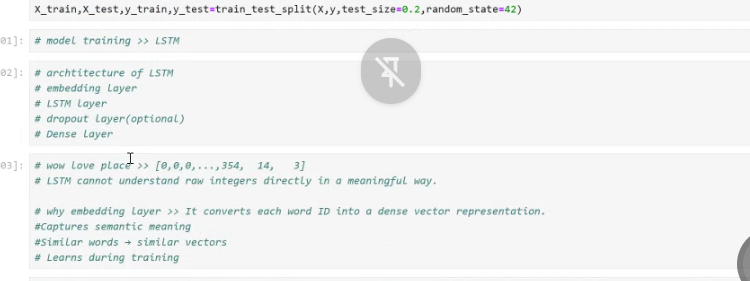

In [96]:
# wow love place >> [123,516,78]
# LSTM cannot understand raw integers directly in a meaningful way.

# why embedding layer >> It converts each word ID into a dense vector representation.
#Captures semantic meaning
#Similar words → similar vectors
# Learns during training




In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM,Dense,Dropout

In [98]:
model=Sequential()
model.add(Embedding(input_dim=max_words,output_dim=28))
model.add(LSTM(128,return_sequences=False))    #128 unit likeno of  nurons
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

In [99]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [100]:
history=model.fit(
    X,
    y,
    epochs=20,
    batch_size=32,
    validation_data=(x_test,y_test)
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.5707 - loss: 0.6728 - val_accuracy: 0.6259 - val_loss: 0.6541
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.6825 - loss: 0.6133 - val_accuracy: 0.7338 - val_loss: 0.5409
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.8348 - loss: 0.3992 - val_accuracy: 0.9029 - val_loss: 0.2773
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.6284 - loss: 2.4839 - val_accuracy: 0.6187 - val_loss: 0.6433
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.7778 - loss: 0.5152 - val_accuracy: 0.8885 - val_loss: 0.4356
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.8817 - loss: 0.3820 - val_accuracy: 0.9173 - val_loss: 0.3107
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.9278 - loss: 0.2614 - val_accuracy: 0.9173 - val_loss: 0.2291
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.9416 - loss: 0.1920 - val_accuracy: 0

In [102]:
loss,accuracy=model.evaluate(x_test,y_test)
print("Test Accuracy:",accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9964 - loss: 0.0190
Test Accuracy: 0.9964028596878052


In [103]:
model.save('lstm_reviews.keras')

In [105]:
y_pred=model.predict(x_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


In [106]:
y_pred1=[  1 if i>0.5 else 0  for i in y_pred]

In [107]:
from sklearn.metrics import confusion_matrix,classification_report

In [108]:
confusion_matrix(y_test,y_pred1)

array([[120,   0],
       [  1, 157]])

In [109]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       120
           1       1.00      0.99      1.00       158

    accuracy                           1.00       278
   macro avg       1.00      1.00      1.00       278
weighted avg       1.00      1.00      1.00       278



In [110]:
# new Review

In [111]:
a='good taste'

In [112]:
def predict_text(text):
    text= text.lower()
    seq = tk.texts_to_sequences([text])
    padded=pad_sequences(seq,maxlen=max_len)
    pred = model.predict(padded)[0][0]


    if pred > 0.5:
        return f"Positive ({pred:.2f})"
    else:
        return f"Negative ({pred:.2f})"
    

In [113]:
predict_text(' bad taste')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


'Negative (0.01)'

In [114]:
df

,Review,Liked
0,wow love place,1
1,crust not good,0
2,not tasti textur nasti,0
3,stop late may bank holiday rick steve recommen...,1
4,select menu great price,1
...,...,...
1381,clean,1
1382,less,0
1383,clean,1
1384,less,0


In [115]:

# this project we have to deplyment
# 1) potato desciation
# 2) LSTM
# 3) chatbot
